# IOAI Preparation notebook
This notebook covers as much as possible from the 2026 IOAI syllabus. It only covers the practice part. Make sure to explore the theory yourself. Refer to the syllabus at https://ioai-official.org/wp-content/uploads/2025/10/Syllabus.pdf

# 1 Foundational Skills & Classical Machine Learning
classical machine learning can be divided into supervised and unsupervised learning. Supervised learning is the most common type of machine learning. It is used when we have labeled data, meaning that we have input-output pairs. The goal of supervised learning is to learn a mapping from inputs to outputs, so that we can make predictions on new, unseen data. Unsupervised learning, on the other hand, is used when we have unlabeled data, meaning that we only have inputs and no corresponding outputs. The goal of unsupervised learning is to find patterns or structure in the data, such as clustering similar data points together or reducing the dimensionality of the data.

## Supervised Learning
the following algorithms are listed in the syllabus:
- Linear Regression Both
- Logistic Regression Both
- L1 & L2 Regularization Both
- K-Nearest Neighbors (K-NN) Both
- Decision Trees Both
- Model Ensembles (Gradient Boosting, Bagging,Random Forest) Practice
- Support Vector Machines (SVM) Both

in the following we demonstrate their usage in python using the sklearn library. We will use the iris dataset for classification and the boston housing dataset for regression. We will not cover the theory behind these algorithms. Generally speaking, CARTS perform best and the only reason not to use them is that they are not interpretable. For regression, linear regression is the most interpretable model and should be used when interpretability is important. For classification, logistic regression is the most interpretable model and should be used when interpretability is important. K-NN is a simple algorithm that can be used for both regression and classification. SVMs are powerful algorithms that can be used for both regression and classification, but they are not interpretable. Model ensembles are powerful algorithms that can be used for both regression and classification, but they are not interpretable.

### Setup

In [1]:
import sklearn
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, load_wine, load_diabetes
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns

# classification dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# unsupervised dataset (13 features, more useful for dimensionality reduction)
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# regression dataset (boston was removed from sklearn)
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

print(df_diabetes.head())
print(df_iris.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1   

### Classification

#### Visualization

here we cover unsupervised learning. We will use the wine dataset for this purpose. The wine dataset is a classic dataset that contains information about different types of wine. It has 13 features and 3 classes. The goal is to reduce the dimensionality of the dataset to 2 dimensions so that we can visualize it.

##### PCA
PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. PCA is sensitive to the relative scaling of the original variables. It is often used as a preprocessing step for other machine learning algorithms.

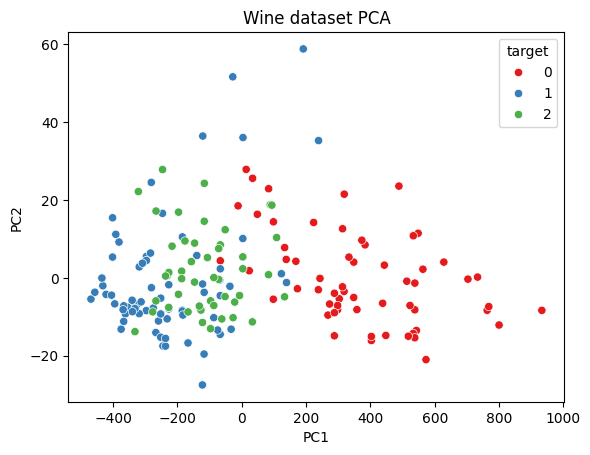

In [2]:
# import PCA
from sklearn.decomposition import PCA
PCA_model = PCA(n_components=2)
wine_pca = PCA_model.fit_transform(df_wine)
df_wine_pca = pd.DataFrame(wine_pca, columns=['PC1', 'PC2'])
df_wine_pca['target'] = wine.target
sns.scatterplot(data=df_wine_pca, x='PC1', y='PC2', hue='target', palette='Set1')
plt.title('Wine dataset PCA')
plt.show()

##### t-SNE
t-SNE is a nonlinear dimensionality reduction technique that transforms the data into a new coordinate system such that the points are more likely to be close together than they are far apart.

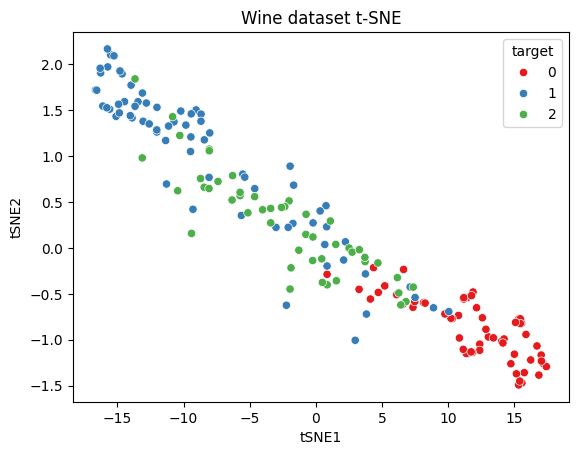

In [3]:
from sklearn.manifold import TSNE
tsne_model = TSNE(n_components=2, random_state=42)
wine_tsne = tsne_model.fit_transform(df_wine)
df_wine_tsne = pd.DataFrame(wine_tsne, columns=['tSNE1', 'tSNE2'])
df_wine_tsne['target'] = wine.target
sns.scatterplot(data=df_wine_tsne, x='tSNE1', y='tSNE2', hue='target', palette='Set1')
plt.title('Wine dataset t-SNE')
plt.show()

##### UMAP
UMAP is a nonlinear dimensionality reduction technique that is similar to t-SNE but is faster and scales better to large datasets. It is based on manifold learning and topological data analysis.

In [4]:
%pip install umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\pstay\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


C:\Users\pstay\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\pstay\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


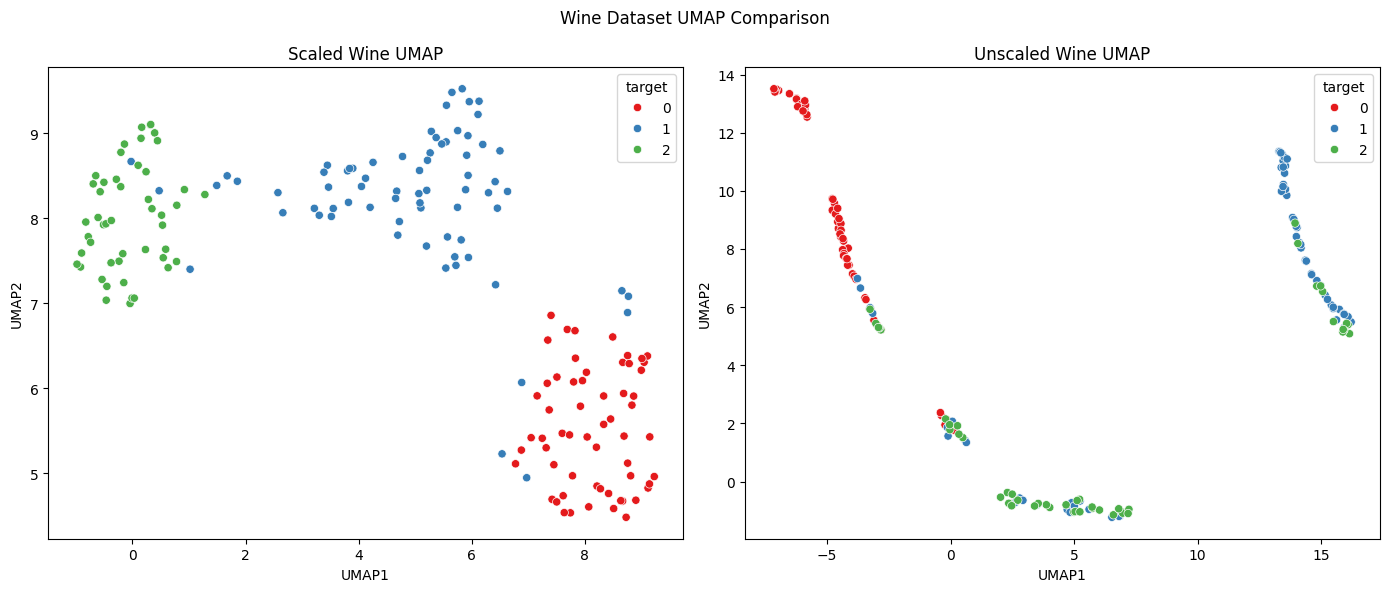

In [5]:
import umap
from sklearn.preprocessing import StandardScaler

# Scaled: standardize features so each contributes equally to the distances UMAP uses
scaled_wine = StandardScaler().fit_transform(df_wine)
wine_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(scaled_wine)

# Unscaled: raw wine features (proline dominates the distances)
wine_umap_unscaled = umap.UMAP(n_components=2, random_state=42).fit_transform(df_wine)

df_wine_umap = pd.DataFrame(wine_umap, columns=['UMAP1', 'UMAP2'])
df_wine_umap['target'] = wine.target

df_wine_umap_unscaled = pd.DataFrame(wine_umap_unscaled, columns=['UMAP1', 'UMAP2'])
df_wine_umap_unscaled['target'] = wine.target

# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_wine_umap, x='UMAP1', y='UMAP2', hue='target', palette='Set1', ax=ax[0])
ax[0].set_title('Scaled Wine UMAP')

sns.scatterplot(data=df_wine_umap_unscaled, x='UMAP1', y='UMAP2', hue='target', palette='Set1', ax=ax[1])
ax[1].set_title('Unscaled Wine UMAP')

plt.suptitle('Wine Dataset UMAP Comparison')
plt.tight_layout()
plt.show()

Compare how PCA, t-SNE and UMAP separate the three wine classes. PCA is linear and keeps global variance, while t-SNE and UMAP are nonlinear and preserve local structure; UMAP is also faster than t-SNE and scales better to large datasets. Wine features have very different scales (proline is in the hundreds, others are near 1), so scaling changes the result a lot, especially for PCA and UMAP.

#### Implementation

Accuracy Logistic Regression: 0.97
Depth 5 Decision Tree: 0.90
Depth 10 Decision Tree: 0.90
Depth 15 Decision Tree: 0.90
Depth 20 Decision Tree: 0.90
K 1 K-NN: 0.93
K 2 K-NN: 0.93
K 3 K-NN: 0.93
K 4 K-NN: 0.90
K 5 K-NN: 0.93
K 6 K-NN: 0.93
K 7 K-NN: 0.97
K 8 K-NN: 0.93
K 9 K-NN: 0.97
K 10 K-NN: 0.97
Kernel linear SVM: 0.93
Kernel poly SVM: 0.90
Kernel rbf SVM: 0.97
Kernel sigmoid SVM: 0.23


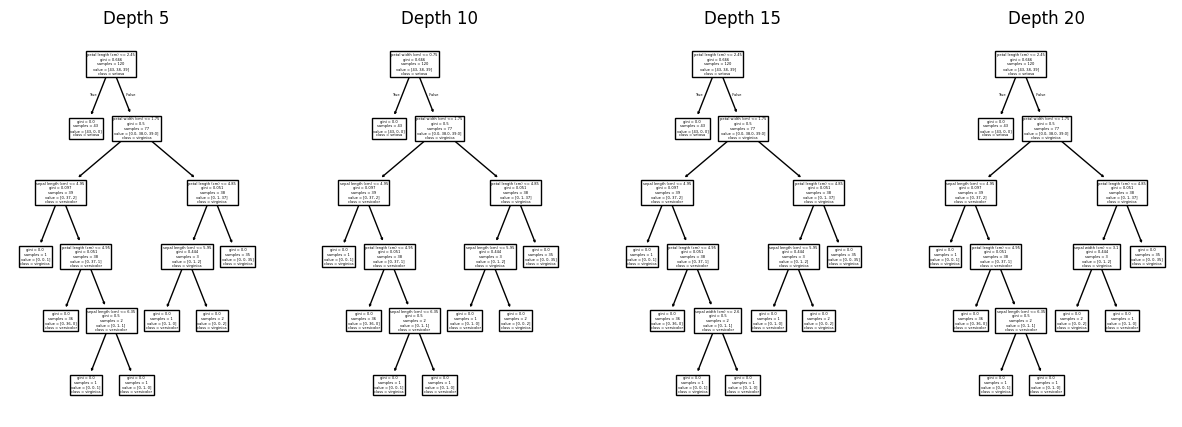

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

X, X_test, y, y_test = train_test_split(df_iris, load_iris().target, test_size=0.2, shuffle=True)

# Logistic Regression
logReg = LogisticRegression(max_iter=1000)
logReg.fit(X, y)
y_pred = logReg.predict(X_test)
print(f"Accuracy Logistic Regression: {logReg.score(X_test, y_test):.2f}")

fix, axes = plt.subplots(1, 4, figsize=(15, 5))

# Decision Tree
for i in range(5,21,5):
    tree=DecisionTreeClassifier(max_depth=i)
    print(f"Depth {i} Decision Tree: {tree.fit(X, y).score(X_test, y_test):.2f}")
    plot_tree(tree, ax=axes[(i-5)//4], feature_names=load_iris().feature_names, class_names=load_iris().target_names)
    axes[(i-5)//4].set_title(f"Depth {i}")

# K-Nearest Neighbors
for i in range(1,11):
    print(f"K {i} K-NN: {KNeighborsClassifier(n_neighbors=i).fit(X, y).score(X_test, y_test):.2f}")


# Support Vector Machine
for i in ['linear', 'poly', 'rbf', 'sigmoid']:
    print(f"Kernel {i} SVM: {SVC(kernel=i).fit(X, y).score(X_test, y_test):.2f}")

#### Evaluation metrics
Accuracy alone hides which classes a model confuses with each other, especially once classes are imbalanced. We look at a confusion matrix together with precision, recall and F1 (macro-averaged over the 3 iris classes) for one representative version of each model.

==========Logistic Regression==========
Accuracy:  0.97
Precision: 0.97
Recall:    0.97
F1:        0.97
==========Decision Tree (depth=5)==========
Accuracy:  0.90
Precision: 0.92
Recall:    0.91
F1:        0.91
==========K-NN (k=5)==========
Accuracy:  0.93
Precision: 0.95
Recall:    0.94
F1:        0.94
==========SVM (rbf)==========
Accuracy:  0.97
Precision: 0.97
Recall:    0.97
F1:        0.97


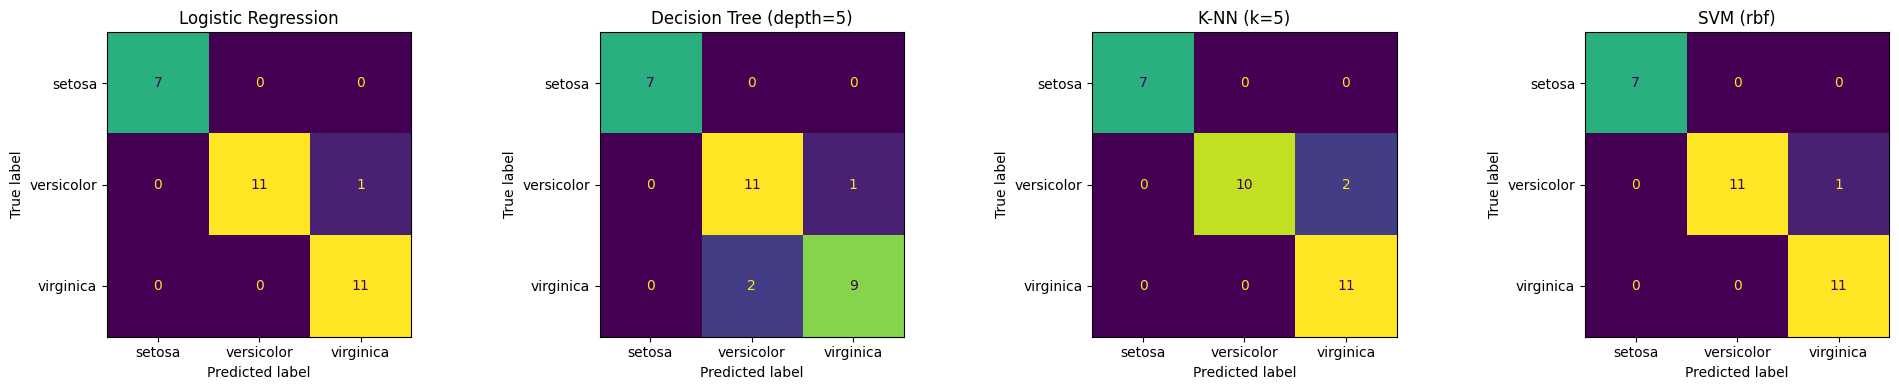

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# one representative fit per model type, evaluated on the held-out test split
final_models = {
    "Logistic Regression": logReg,
    "Decision Tree (depth=5)": DecisionTreeClassifier(max_depth=5).fit(X, y),
    "K-NN (k=5)": KNeighborsClassifier(n_neighbors=5).fit(X, y),
    "SVM (rbf)": SVC(kernel='rbf').fit(X, y),
}

fig, axes = plt.subplots(1, len(final_models), figsize=(20, 4))
for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    print(f"{10*'='}{name}{10*'='}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.2f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='macro'):.2f}")
    print(f"F1:        {f1_score(y_test, y_pred, average='macro'):.2f}")
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred), display_labels=load_iris().target_names
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Regression

#### Visualization
The diabetes dataset has 10 numeric features (age, sex, bmi, blood pressure and six blood serum measurements) and a continuous target: disease progression one year after baseline. First we look at how the features relate to each other and to the target.

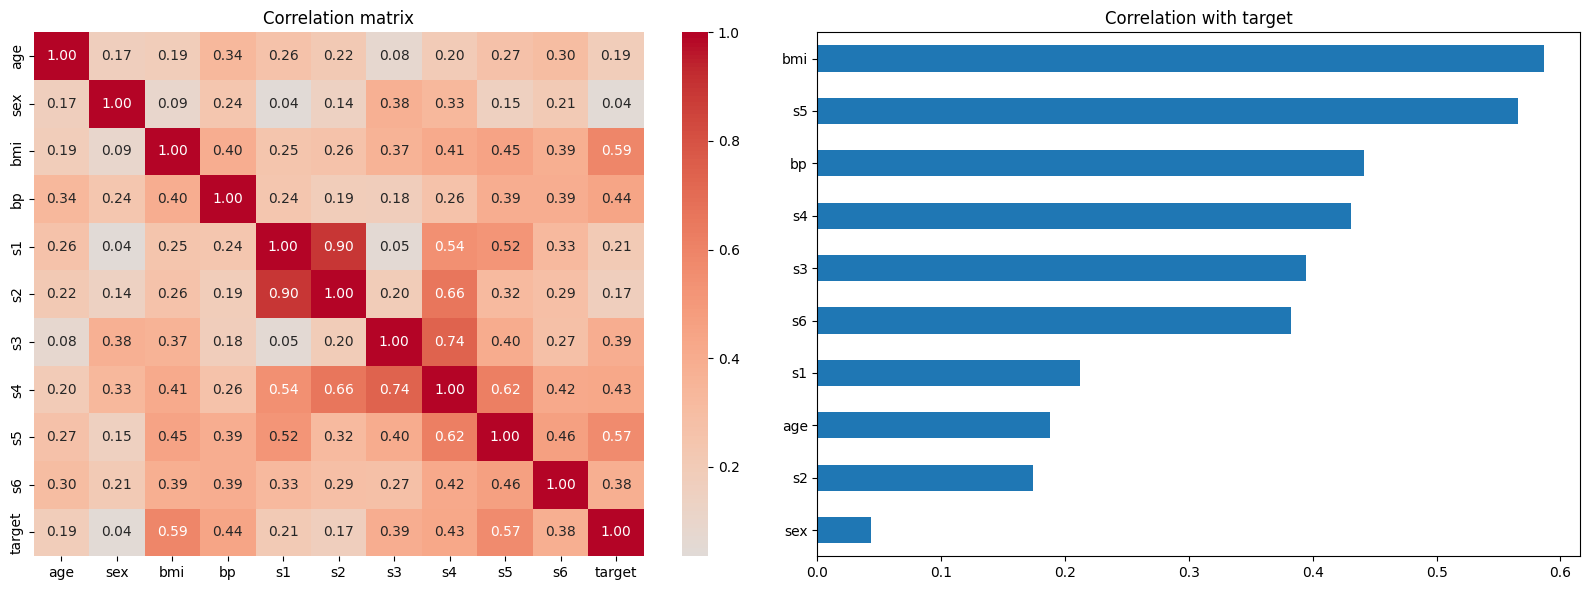

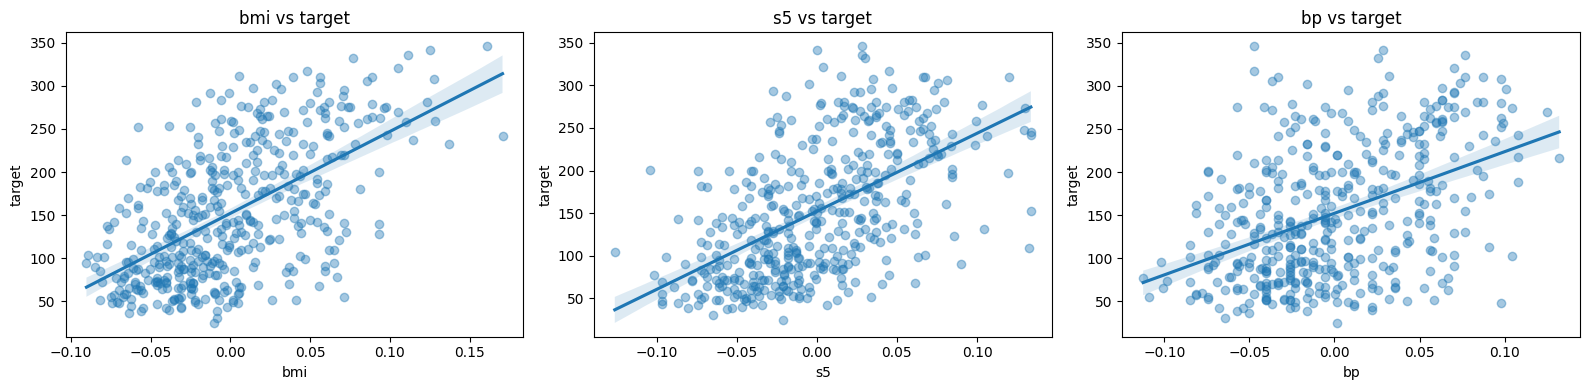

In [8]:
df_diabetes_target = df_diabetes.join(pd.Series(diabetes.target, name='target'))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Correlation between all features and the target
sns.heatmap(df_diabetes_target.corr().abs(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[0])
ax[0].set_title('Correlation matrix')

# Feature correlation with the target, strongest first
df_diabetes.corrwith(pd.Series(diabetes.target)).abs().sort_values().plot.barh(ax=ax[1])
ax[1].set_title('Correlation with target')

plt.tight_layout()
plt.show()

# The most correlated features against the target, with a regression line
top = df_diabetes.corrwith(pd.Series(diabetes.target)).abs().nlargest(3).index
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax, top):
    sns.regplot(data=df_diabetes_target, x=col, y='target', scatter_kws={'alpha': 0.4}, ax=a)
    a.set_title(f'{col} vs target')
plt.tight_layout()
plt.show()

#### Implementation

In [9]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\pstay\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

models = [LinearRegression(), RandomForestRegressor(), SVR(), XGBRegressor()]

for model in models:
    model.fit(df_diabetes, diabetes.target)
    print(f"Accuracy {model.__class__.__name__}: {model.score(df_diabetes, diabetes.target):.2f}")

Accuracy LinearRegression: 0.52


Accuracy RandomForestRegressor: 0.92
Accuracy SVR: 0.21


Accuracy XGBRegressor: 1.00


we see, that the Random Forest and XGBoost models perform best, while Linear Regression and SVR perform worse. This is expected, as Random Forest and XGBoost are ensemble methods that can capture complex relationships in the data, while Linear Regression and SVR are simpler models that may not capture these relationships as well. TLDR: Trees are almost always better than linear models, unless the data is truly linear. You should always try a tree-based model first, and only use linear models if you need interpretability.

#### Refer to the exercise in the second notebook for more practice on regression and classification.